## 1. Importing Libraries
**What is done in this cell:**
We import the core Python libraries required for data manipulation (`pandas`, `numpy`) and data visualization (`matplotlib.pyplot`, `seaborn`). We also configure a global default plotting style (`whitegrid`) and figure size to ensure all charts look clean and consistent.

**Output Explanation:**
There is no visual output for this cell; it merely sets up our coding environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 2. Loading Data and Basic Inspection
**What is done in this cell:**
We load the historical air quality data from the CSV file into a Pandas DataFrame. We then convert the `date` column into standard DateTime objects and set it as the index of the dataframe, which is crucial for time-series analysis.

**Output Explanation:**
- **Shape**: Prints the total number of rows and columns in our dataset.
- **Data Types**: Lists every column and confirms they are properly loaded as numeric types (float64).
- **Table**: Displays the first 5 rows of the dataset so we can visually confirm the data structure.

In [2]:
df = pd.read_csv("C:/Users/lalit/Desktop/Projects/Project AQI/aqi-ahmedabad/data/air_quality_historical.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
display(df.head())

Shape of dataset: (1298, 11)

Data Types:
 pm10                     float64
pm2_5                    float64
carbon_monoxide          float64
nitrogen_dioxide         float64
sulphur_dioxide          float64
ozone                    float64
aerosol_optical_depth    float64
dust                     float64
uv_index                 float64
us_aqi                   float64
european_aqi             float64
dtype: object


,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
date,,,,,,,,,,,
2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-04,36.726316,22.131579,303.157895,22.810526,10.163158,59.473684,0.498947,11.052632,1.594737,NaN,NaN
2022-08-05,28.758333,19.912500,304.416667,23.770833,10.670833,55.166667,0.332083,1.208333,1.295833,70.947368,47.421053


## 3. Missing Value Analysis & Imputation
**What is done in this cell:**
We scan the entire dataframe to count how many `NaN` (blank) values exist in each column and calculate what percentage of the dataset they represent. Since time-series data requires continuous lines, we fill these missing gaps using backwards-fill and forwards-fill methods.

**Output Explanation:**
The output table shows a list of columns that contain missing values along with the exact count and percentage. (In this dataset, the missing values are concentrated in the very first few days of August 2022).

In [3]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
display(missing_df[missing_df['Missing Values'] > 0])

# Fill missing values
df.bfill(inplace=True)
df.ffill(inplace=True)

,Missing Values,Percentage
pm10,3,0.231125
pm2_5,3,0.231125
carbon_monoxide,3,0.231125
nitrogen_dioxide,3,0.231125
sulphur_dioxide,3,0.231125
ozone,3,0.231125
aerosol_optical_depth,3,0.231125
dust,3,0.231125
uv_index,3,0.231125
us_aqi,4,0.308166


## 4. Descriptive Statistics
**What is done in this cell:**
We generate standard summary statistics for all the numerical columns to understand the central tendency, dispersion, and range of our data.

**Output Explanation:**
The output is a transposed statistical table where:
- **Rows**: Represent each distinct pollutant or index (e.g., PM2.5, Ozone, AQI).
- **Columns**: Represent statistical measures: `count`, `mean` (average), `std` (standard deviation/spread), `min`, `max`, and the percentiles (`25%`, `50%` median, `75%`).

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
pm10,1298.0,49.187446,21.641949,1.000000,33.332292,45.125000,62.198958,154.337500
pm2_5,1298.0,30.740942,16.436028,0.704167,17.722917,26.564583,40.143750,115.800000
carbon_monoxide,1298.0,389.564399,195.867415,59.083333,214.135417,370.125000,526.489583,1247.541667
nitrogen_dioxide,1298.0,20.248017,12.230841,0.000000,10.932292,16.758333,26.355208,80.608333
sulphur_dioxide,1298.0,10.989300,5.756790,0.241667,6.213542,10.302083,14.431250,47.575000
ozone,1298.0,68.761604,17.208179,26.208333,54.666667,69.104167,81.656250,119.666667
aerosol_optical_depth,1298.0,0.392806,0.213698,0.030833,0.230937,0.350208,0.510833,1.797083
dust,1298.0,22.048442,27.633000,0.000000,2.625000,11.375000,31.166667,296.000000
uv_index,1298.0,1.592548,0.562953,0.129167,1.137500,1.527083,2.008333,2.947917
us_aqi,1298.0,90.696285,32.811403,15.375000,63.666667,82.937500,112.239583,182.083333


## 5. Distribution of Pollutants (Histograms)
**What is done in this cell:**
We plot histograms for 7 key atmospheric pollutants to visualize how their concentration levels are distributed throughout the 3.5-year period.

**Output Explanation:**
- **X-axis**: Represents the concentration ranges of the pollutant.
- **Y-axis**: Represents the frequency (i.e., how many days that specific concentration range was recorded).
- **Insight**: You will notice most charts are heavily "right-skewed", meaning Ahmedabad mostly experiences lower/moderate levels of these pollutants, with long tails indicating infrequent, extreme pollution events.

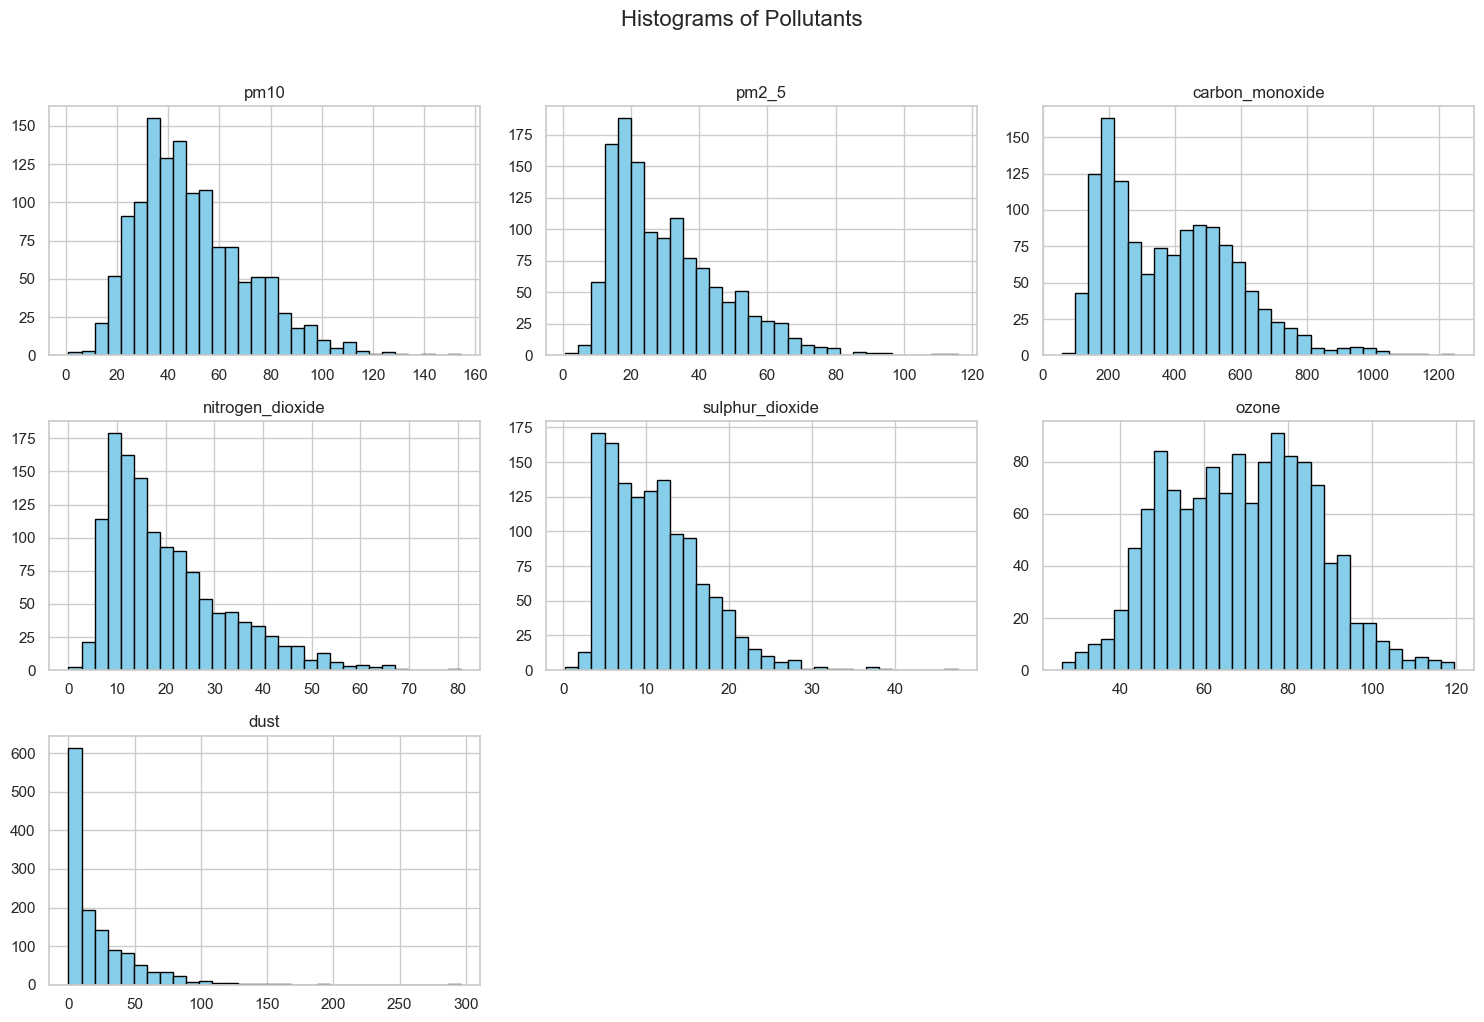

In [5]:
pollutants = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust']
df[pollutants].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Pollutants', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 6. Outlier Detection (Boxplots)
**What is done in this cell:**
We create a horizontal boxplot for our pollutants to easily identify extreme statistical outliers. Because Carbon Monoxide (CO) concentration is measured in much higher baseline numbers than other pollutants, we apply a logarithmic scale to the X-axis so all boxes can be viewed simultaneously.

**Output Explanation:**
- **Y-axis**: The different pollutants.
- **X-axis**: The pollutant concentration plotted on a Log-10 scale.
- **Insight**: The solid colored boxes represent the middle 50% of the data (Interquartile Range). The dark dots located far to the right of the "whiskers" represent days with extreme, anomalous pollution.

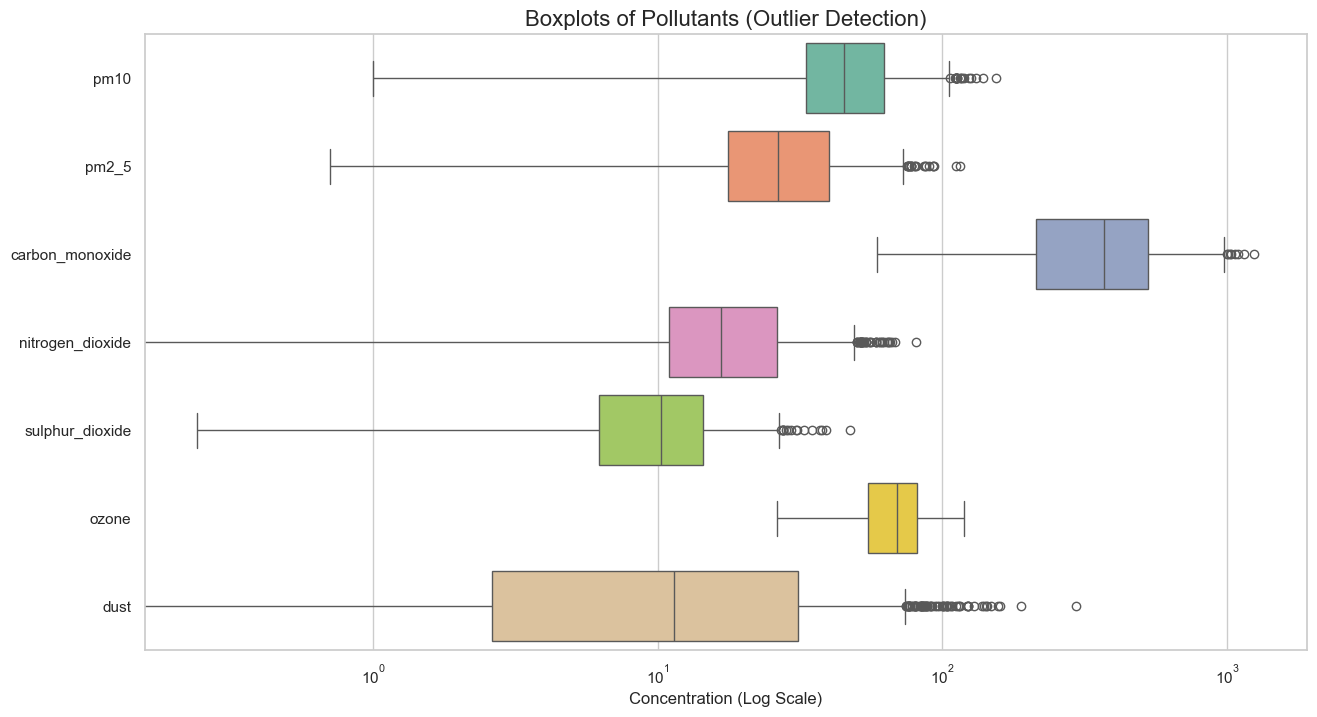

In [6]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[pollutants], orient='h', palette='Set2')
plt.title('Boxplots of Pollutants (Outlier Detection)', fontsize=16)
plt.xscale('log')
plt.xlabel('Concentration (Log Scale)')
plt.show()

## 7. Time Series Analysis: AQI over 3.5 Years
**What is done in this cell:**
We plot the daily US Air Quality Index (AQI) as a continuous line graph across the entire timeframe of the dataset to visualize macro trends.

**Output Explanation:**
- **X-axis**: The timeline (Dates).
- **Y-axis**: The US AQI numerical value.
- **Threshold Lines**: The red dashed line marks an AQI of 100 (Unhealthy for Sensitive Groups). The solid dark red line marks an AQI of 150 (Strictly Unhealthy). You can easily see the dense cyclical peaks crossing into the dangerous zones.

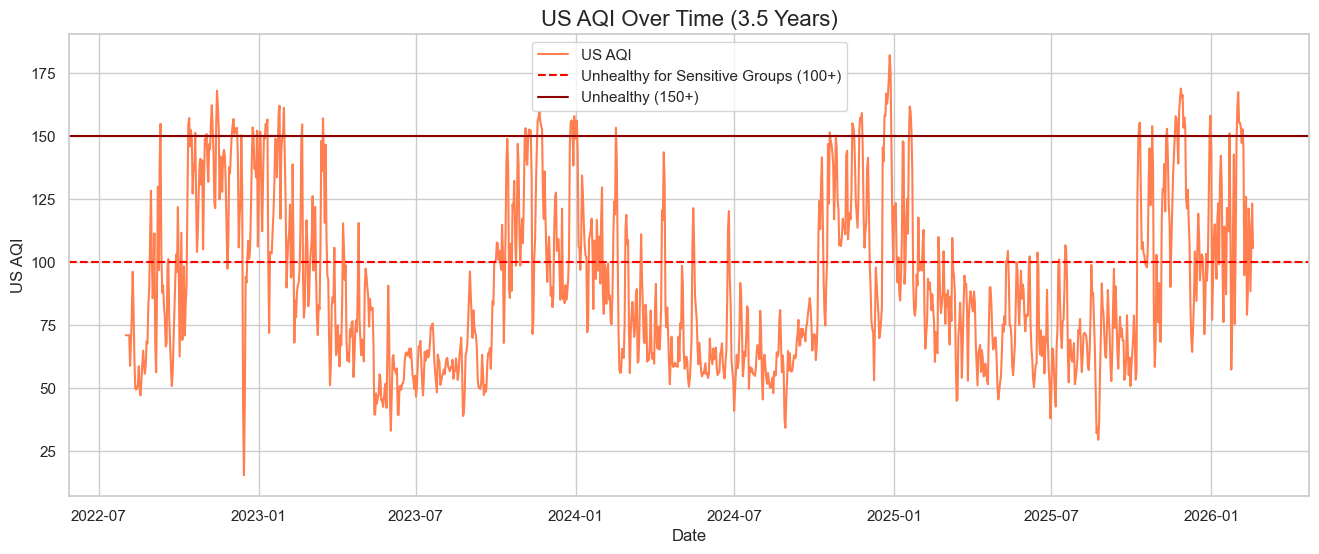

In [7]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=df, x=df.index, y='us_aqi', color='coral', label='US AQI')
plt.axhline(100, color='red', linestyle='--', label='Unhealthy for Sensitive Groups (100+)')
plt.axhline(150, color='darkred', linestyle='-', label='Unhealthy (150+)')
plt.title('US AQI Over Time (3.5 Years)', fontsize=16)
plt.ylabel('US AQI')
plt.xlabel('Date')
plt.legend()
plt.show()

## 8. Monthly Average AQI
**What is done in this cell:**
Daily fluctuations can be noisy. Here, we group the dataset by month and calculate the mean AQI for each specific month, rendering it as a bar chart.

**Output Explanation:**
- **X-axis**: Specific Year-Month pairings (e.g., 2022-08, 2022-09).
- **Y-axis**: The average US AQI for that 30-day block.
- **Insight**: This smooths the data out and reveals massive macro-level oscillations. You can clearly see a "wave" pattern rising in winter months and falling drastically during the summer/monsoons.

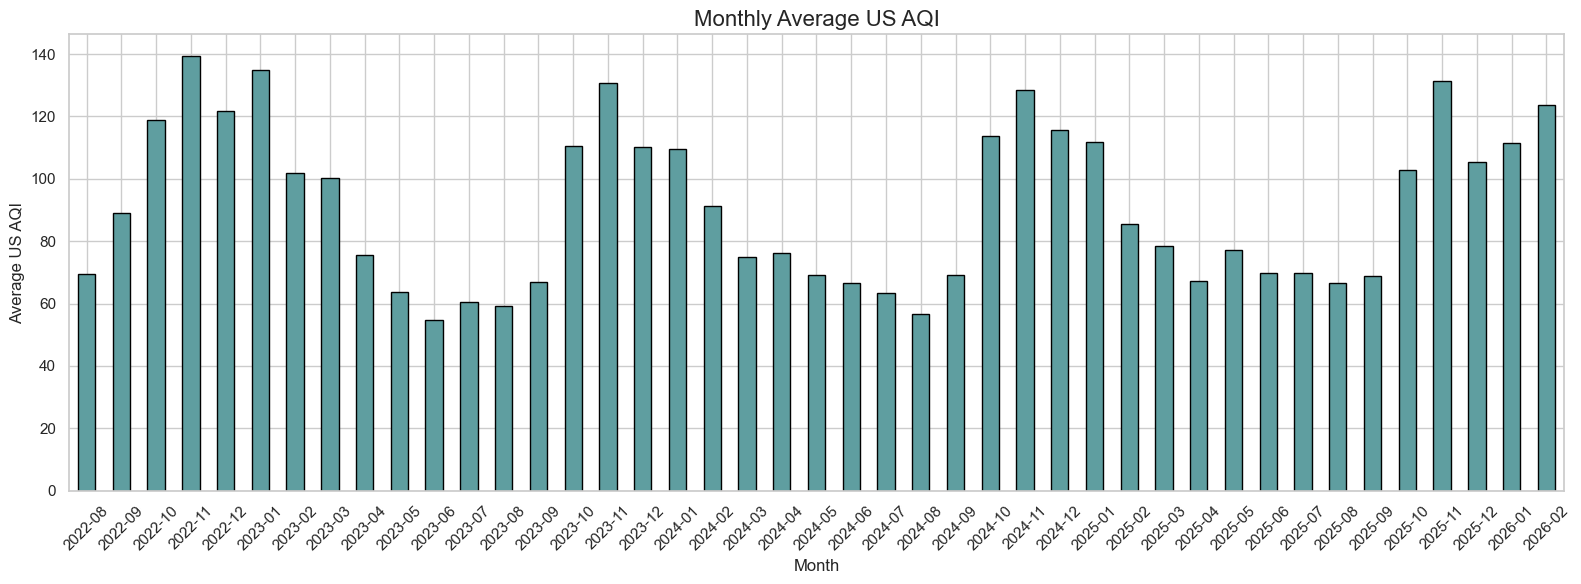

In [8]:
monthly_aqi = df['us_aqi'].resample('M').mean()
plt.figure(figsize=(16, 6))
monthly_aqi.plot(kind='bar', color='cadetblue', edgecolor='black')
plt.title('Monthly Average US AQI', fontsize=16)
plt.ylabel('Average US AQI')
plt.xlabel('Month')
plt.xticks(ticks=range(len(monthly_aqi)), labels=[x.strftime('%Y-%m') for x in monthly_aqi.index], rotation=45)
plt.tight_layout()
plt.show()

## 9. Yearly AQI Comparison
**What is done in this cell:**
We extract the year from our dataset index and plot a side-by-side boxplot. This lets us check if air pollution in Ahmedabad is generally improving or degrading on a year-by-year scale.

**Output Explanation:**
- **X-axis**: The calendar year.
- **Y-axis**: The distribution of AQI values.
- **Insight**: Comparing the medians (the horizontal line inside the boxes) and the upper whiskers tells us if the baseline pollution or extreme pollution events are growing over the years.

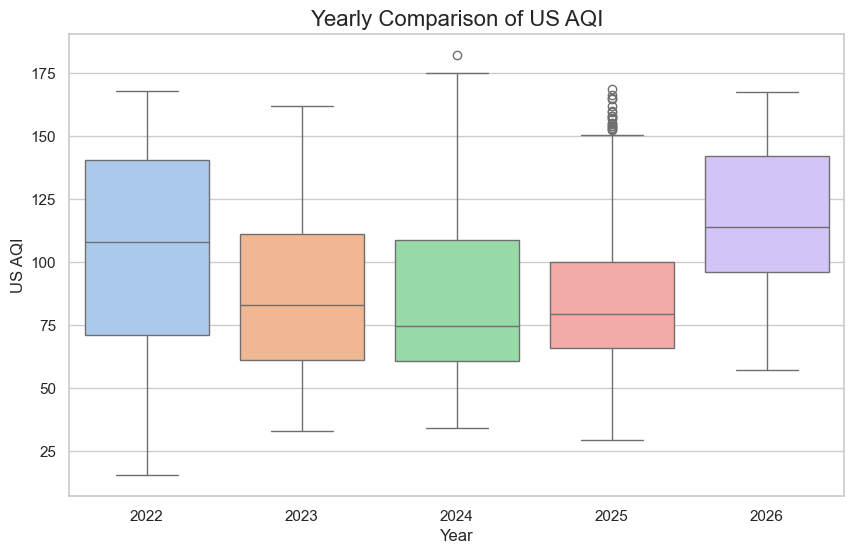

In [9]:
df['year'] = df.index.year
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='year', y='us_aqi', palette='pastel')
plt.title('Yearly Comparison of US AQI', fontsize=16)
plt.ylabel('US AQI')
plt.xlabel('Year')
plt.show()

## 10. Seasonal Impact on Air Quality
**What is done in this cell:**
We classify every row of data into one of four Indian seasons based on its month: Winter (Dec-Feb), Summer (Mar-May), Monsoon (Jun-Sep), or Post-Monsoon (Oct-Nov). We then plot a boxplot comparing the AQI across these seasons.

**Output Explanation:**
- **X-axis**: The four defined seasons.
- **Y-axis**: The AQI distribution.
- **Insight**: The Monsoon season significantly suppresses pollution (rain washes particulates out of the air), while Winter strongly exacerbates it (cold air traps pollutants closer to the ground).

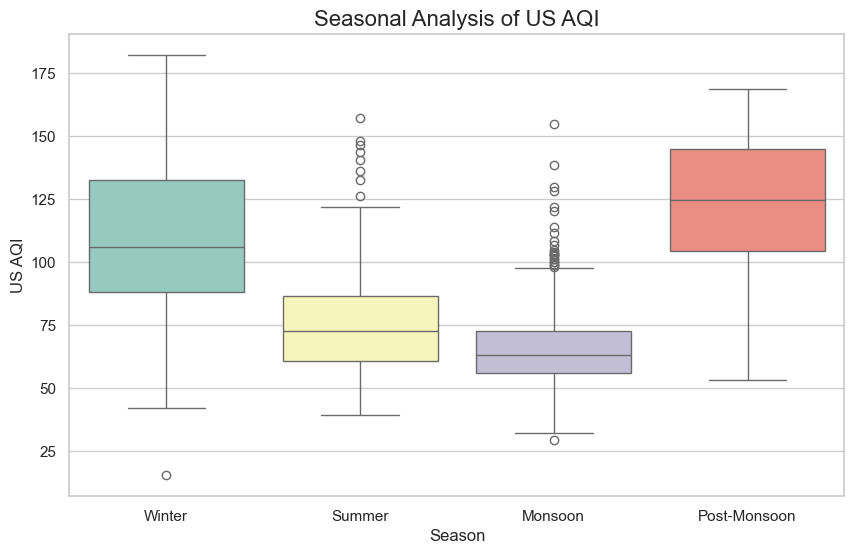

In [10]:
df['month'] = df.index.month
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8, 9]: return 'Monsoon'
    else: return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='season', y='us_aqi', order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'], palette='Set3')
plt.title('Seasonal Analysis of US AQI', fontsize=16)
plt.ylabel('US AQI')
plt.xlabel('Season')
plt.show()

## 11. Festival Impact: Diwali AQI Spikes
**What is done in this cell:**
The festival of Diwali is notorious for massive temporary drops in air quality due to firecrackers. We slice out narrow 30-day windows around Diwali 2022 (Oct 24) and Diwali 2023 (Nov 12) and plot them side-by-side to observe the exact impact.

**Output Explanation:**
- **Two Subplots**: The left chart is for 2022, the right chart is for 2023.
- **X-axis**: Narrow window of daily dates.
- **Y-axis**: US AQI magnitude.
- **Insight**: Look closely at the exact dates corresponding to the festival. You will typically see a sharp, sudden spike on the exact date or the morning after, highlighting the immediate environmental impact of the festivities.

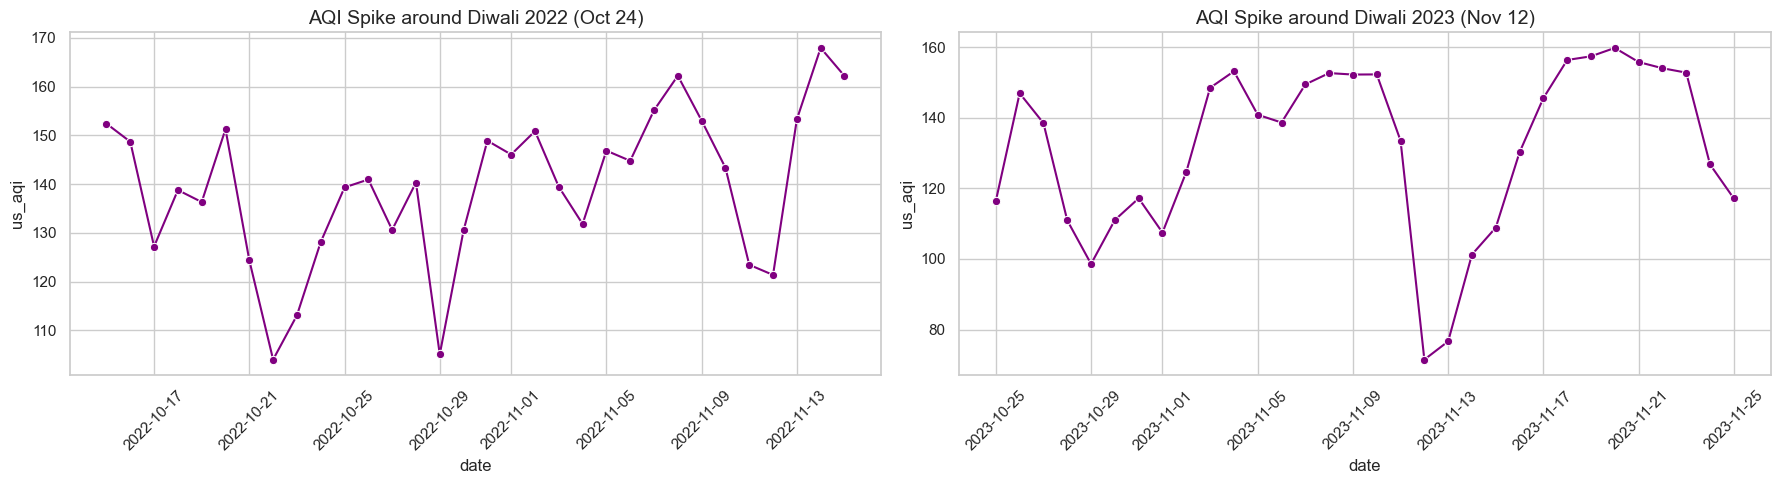

In [11]:
# Diwali in 2022 was Oct 24, and in 2023 was Nov 12
diwali_2022 = df.loc['2022-10-15':'2022-11-15']
diwali_2023 = df.loc['2023-10-25':'2023-11-25']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.lineplot(data=diwali_2022, x=diwali_2022.index, y='us_aqi', ax=axes[0], marker='o', color='purple')
axes[0].set_title('AQI Spike around Diwali 2022 (Oct 24)', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=diwali_2023, x=diwali_2023.index, y='us_aqi', ax=axes[1], marker='o', color='purple')
axes[1].set_title('AQI Spike around Diwali 2023 (Nov 12)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 12. Correlation Between Pollutants
**What is done in this cell:**
We calculate the Pearson correlation coefficients for all major numerical fields (including index fields like UV and AOD) and project it onto a colored heatmap.

**Output Explanation:**
- **Grid**: Every variable is mapped against every other variable.
- **Colors & Values**: Scores range from -1 (perfect negative correlation) to 1 (perfect positive correlation). 
- **Insight**: A dark green square of `0.98` between PM2.5 and US AQI indicates that PM2.5 levels almost perfectly dictate the AQI. Conversely, you can see how things like UV index correlate (or fail to correlate) with ground pollutants.

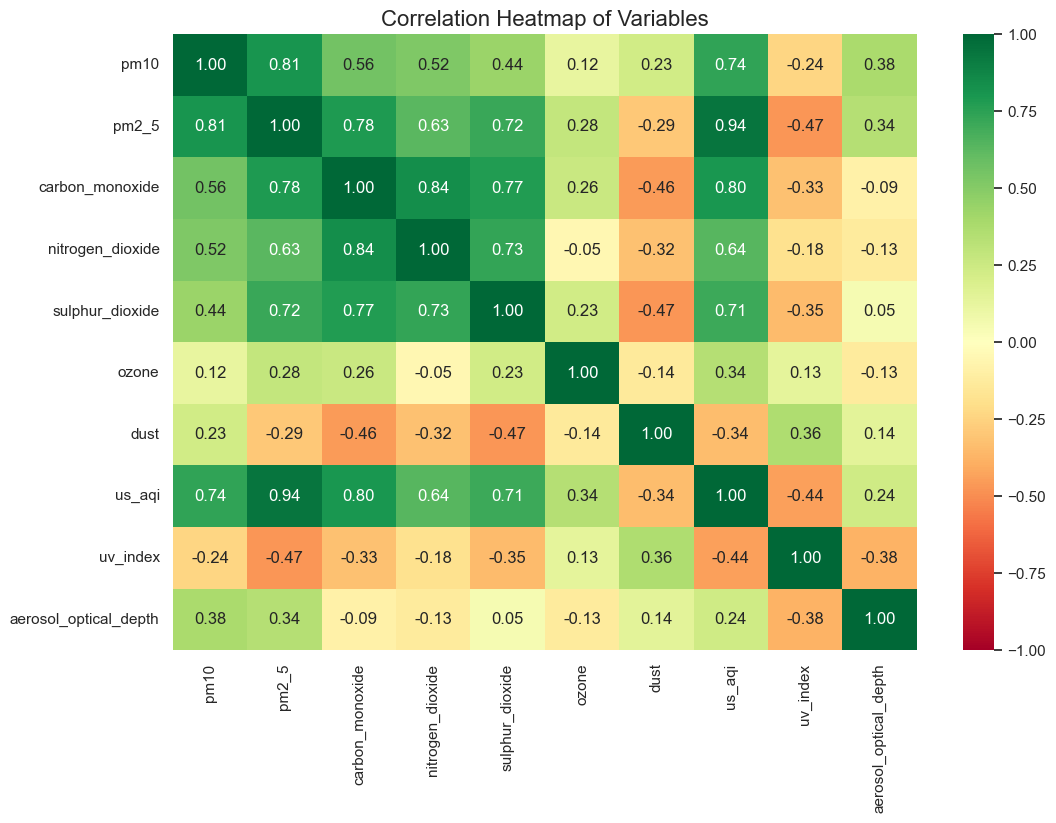

In [12]:
plt.figure(figsize=(12, 8))
cols_to_corr = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 
                'ozone', 'dust', 'us_aqi', 'uv_index', 'aerosol_optical_depth']
corr = df[cols_to_corr].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Variables', fontsize=16)
plt.show()

## 13. PM2.5 vs US AQI Scatter Plot
**What is done in this cell:**
We plot individual points representing each day to visualize the mathematical relationship between the concentration of PM2.5 and the resulting AQI score. We also color-code each dot by season.

**Output Explanation:**
- **X-axis**: PM2.5 Concentration.
- **Y-axis**: US AQI Output.
- **Colors**: Distinct colors mapping to the 4 seasons.
- **Insight**: Notice the distinct linear clusters. Also notice how the extreme upper-right corner (high PM2.5, high AQI) is heavily dominated by dots belonging to the Winter and Post-Monsoon seasons.

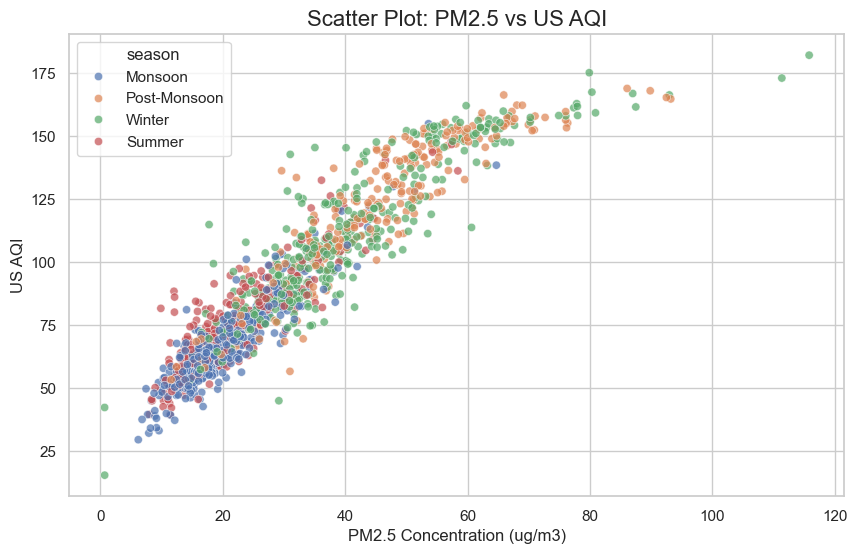

In [13]:
plt.figure(figsize=(10, 6))

# Safety check in case Cell 10 wasn't run first:
if 'season' not in df.columns:
    df['month'] = df.index.month
    df['season'] = df['month'].apply(lambda m: 'Winter' if m in [12, 1, 2] else ('Summer' if m in [3, 4, 5] else ('Monsoon' if m in [6, 7, 8, 9] else 'Post-Monsoon')))

sns.scatterplot(data=df, x='pm2_5', y='us_aqi', hue='season', alpha=0.7)
plt.title('Scatter Plot: PM2.5 vs US AQI', fontsize=16)
plt.xlabel('PM2.5 Concentration (ug/m3)')
plt.ylabel('US AQI')
plt.show()

## 14. Top 10 Worst Air Quality Days
**What is done in this cell:**
We programmatically filter the dataframe to find the top 10 single days that had the absolute highest US AQI values over the 3.5 year period.

**Output Explanation:**
A clean tabular dataframe displaying the date index, along with the AQI, primary PM pollutants, carbon monoxide, and the season for the 10 most extreme events.

In [14]:
worst_days = df.nlargest(10, 'us_aqi')[['us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'season']]
print("Top 10 Worst AQI Days:\n")
display(worst_days)

Top 10 Worst AQI Days:



,us_aqi,pm2_5,pm10,carbon_monoxide,season
date,,,,,
2024-12-27,182.083333,115.800000,117.358333,582.375000,Winter
2024-12-28,175.125000,79.883333,81.166667,571.708333,Winter
2024-12-26,173.000000,111.337500,112.412500,574.041667,Winter
2025-11-27,168.875000,86.062500,87.175000,658.958333,Post-Monsoon
2022-11-14,167.958333,89.837500,131.054167,978.000000,Post-Monsoon
2026-02-01,167.416667,80.308333,82.054167,560.833333,Winter
2024-12-23,166.875000,86.975000,88.020833,587.791667,Winter
2024-12-25,166.291667,92.958333,93.858333,579.291667,Winter
2025-11-29,166.291667,65.908333,66.666667,573.666667,Post-Monsoon


## 15. UV Index vs Aerosol Optical Depth (AOD)
**What is done in this cell:**
We investigate two specialized environmental metrics—UV Index and Aerosol Optical Depth (AOD). Because they operate on entirely different scales, we plot them together on a dual-axis chart.

**Output Explanation:**
- **X-axis**: Timeline (Dates).
- **Left Y-axis (Blue)**: Magnitude of the UV Index.
- **Right Y-axis (Green)**: Magnitude of Aerosol Optical Depth (how much sunlight is prevented from reaching the ground by airborne particles).
- **Insight**: You can visually assess if the cycles overlap. Interestingly, high AOD can sometimes suppress UV by blocking solar radiation.

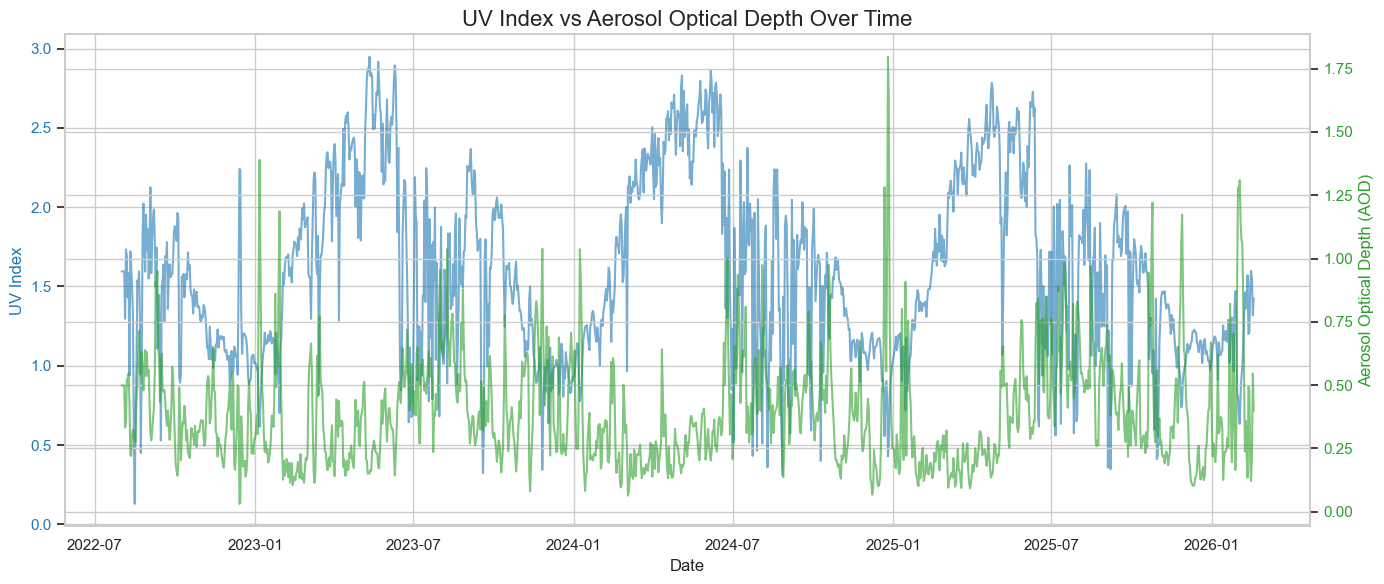

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('UV Index', color=color)
ax1.plot(df.index, df['uv_index'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Aerosol Optical Depth (AOD)', color=color)  
ax2.plot(df.index, df['aerosol_optical_depth'], color=color, alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('UV Index vs Aerosol Optical Depth Over Time', fontsize=16)
fig.tight_layout()  
plt.show()

## 16. Summary Findings

1. **Data Completeness**: The dataset had a few missing values right at the beginning, which were safely back-filled to allow for continuous time-series modeling.
2. **Pollutant Distributions**: Pollutants like PM2.5, PM10, and CO exhibit heavily right-skewed distributions, indicating occasional extreme pollution events (outliers as seen in the boxplots).
3. **AQI Over Time**: The time series reveals that AQI frequently crosses the 'Unhealthy for Sensitive Groups' threshold, with several periods crossing into the strictly 'Unhealthy' zone.
4. **Seasonality & Yearly Comparison**: There is a clear seasonal pattern. Winter and Post-Monsoon months exhibit the highest AQI levels (worse air quality), while the Monsoon season shows the lowest AQI due to rain washing away particulates.
5. **Festival Spikes**: Zooming in on the Diwali periods in October/November shows distinct, sharp spikes in AQI corresponding to the days immediately following the festival.
6. **Correlations**: PM2.5 and PM10 are near-perfectly correlated with the overall US AQI. Carbon monoxide also shows a strong positive correlation with particulate matter.
7. **Worst Days**: The days with the highest AQI predominantly fall in the Winter season, driven heavily by spikes in PM2.5 and PM10.